## Redes neuronales para el reconocimiento de voz a partir de espectrogramas


Se aplicarán redes neuronales convolucionales (CNN) en la aplicacion de clasificación multiclase basado en el procesamiento de señales en imagenes utilizando aprendizaje supervisado. Además de explorar herramientas para el desarrollo de modelos desde cero de redes neuronales, procesos de monitoreo de entrenamiento y bitacoras.

* Se revisará cuantos elementos tiene el archivo de datos de audio
* Se realizara la conversion de estos datos de audio a imagenes, especificamente un espectograma


#### Revision de elementos


In [1]:
import os 
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

ruta = "/home/julio/Documents/IA/Proyecto/audio" 
extension = '.wav'

#listar los archivos y filtrar por extension 

try: 
    contador = len([archivo for archivo in os.listdir(ruta) if archivo.endswith(extension)])
    print(f'El total de archivos {extension} es: {contador}')
except FileNotFoundError:
    print("la ruta no existe")

El total de archivos .wav es: 2000


---

#### Conversion de elementos .wav a espectogramas 224x224

Se utiliza librosa para obtener con la FFT la frecuencia de muestreo para cada uno de los audios y poder construir los espectogramas con estas, ademas se hace en formato RGB con 3 canales para aumentar la informacion de cada imagen

In [3]:
#import librosa
#import numpy as np
#import matplotlib.cm as cm
#from PIL import Image
#from pathlib import Path

#ef wav_a_espectrograma_color_224(ruta_audio, ruta_salida_png, n_mels=224, cmap_name='magma'):
 #   try:
  #      # Cargar audio y calcular el Mel-espectrograma
   #     y, sr = librosa.load(ruta_audio, sr=None, mono=True)
    #    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, fmax=sr/2)
     #   S_db = librosa.power_to_db(S, ref=np.max)

        # Normalizar a 0-1 y aplicar color
      #  S_norm = (S_db - S_db.min()) / (S_db.max() - S_db.min() + 1e-8)
       # S_norm = np.flipud(S_norm) # Voltear para que bajas frecuencias queden abajo
        
       # cmap = cm.get_cmap(cmap_name)
       # colored = (cmap(S_norm)[..., :3] * 255).astype(np.uint8) # Aplicar colormap RGB

        # Redimensionar y guardar
       # im = Image.fromarray(colored, mode="RGB").resize((224, 224), Image.BILINEAR)
       # Path(ruta_salida_png).parent.mkdir(parents=True, exist_ok=True)
       # im.save(ruta_salida_png)

       # print(f"Espectrograma creado: {ruta_salida_png}")

   # except Exception as e:
    #    print(f"Error al procesar {ruta_audio}: {e}")



#carpeta_audios = Path('D:/TEC/2 semestre 2025/IA/Proyecto/dataset/ESC-50-master/audio')
#carpeta_salida = Path('D:/TEC/2 semestre 2025/IA/Proyecto/dataset/espectrogramas')
#carpeta_salida.mkdir(parents=True, exist_ok=True) # Crea la carpeta si no existe

# CONVERTIR TODOS LOS AUDIOS .WAV
#for wav_path in carpeta_audios.glob('*.wav'):
#    ruta_png = carpeta_salida / f"{wav_path.stem}.png"
#    wav_a_espectrograma_color_224(wav_path, ruta_png, cmap_name='magma')

---

#### Carga de la metadata


Se debe cargar la metadata del dataset ESC-50 es importante ya que nos da caracteristicas puntuales acerca de cada audio transformado en un espectograma, los cuales deberiamos mapear a cada una de las celdas contenidas dentro del csv


In [2]:
import pandas as pd

df = pd.read_csv("/home/julio/Documents/IA/Proyecto/meta/esc50.csv")
print(df.head())

            filename  fold  target        category  esc10  src_file take
0   1-100032-A-0.wav     1       0             dog   True    100032    A
1  1-100038-A-14.wav     1      14  chirping_birds  False    100038    A
2  1-100210-A-36.wav     1      36  vacuum_cleaner  False    100210    A
3  1-100210-B-36.wav     1      36  vacuum_cleaner  False    100210    B
4  1-101296-A-19.wav     1      19    thunderstorm  False    101296    A


Se puede visualizar que son 2000 filas cada una con diferentes columnas de las cuales se obtiene informacion relevante para el proceso de pre entrenamiento.

In [3]:
import os
import random
import numpy as np
from PIL import Image, ImageOps, ImageFilter

# === Técnica 1: SpecAugment leve ===
def spec_augment_rgb(mel_rgb, F=8, T=20, mF=1, mT=1):
    num_mels, num_frames, _ = mel_rgb.shape

    # Frequency mask
    for _ in range(mF):
        f = random.randint(0, F)
        if f == 0: continue
        f0 = random.randint(0, num_mels - f)
        mel_rgb[f0:f0+f, :, :] = 0.0

    # Time mask
    for _ in range(mT):
        t = random.randint(0, T)
        if t == 0: continue
        t0 = random.randint(0, num_frames - t)
        mel_rgb[:, t0:t0+t, :] = 0.0

    return mel_rgb


# === Técnica 2: Agregar ruido leve ===
def add_noise_rgb(mel_rgb, noise_std=0.02):
    noise = np.random.normal(0, noise_std, mel_rgb.shape)
    mel_rgb = np.clip(mel_rgb + noise, 0.0, 1.0)
    return mel_rgb


# === Técnica 3: Shift aleatorio ===
def random_shift_rgb(mel_rgb, max_shift_freq=10, max_shift_time=15):
    shift_y = random.randint(-max_shift_freq, max_shift_freq)
    shift_x = random.randint(-max_shift_time, max_shift_time)
    mel_rgb = np.roll(mel_rgb, shift_y, axis=0)
    mel_rgb = np.roll(mel_rgb, shift_x, axis=1)
    return mel_rgb


# === Aplicación masiva con política 50/50 + 33% ===
input_dir = "/home/julio/Documents/IA/Proyecto/espectrogramas"      # carpeta original 
output_dir = "/home/julio/Documents/IA/Proyecto/augmentation"      # carpeta destino


os.makedirs(output_dir, exist_ok=True)
valid_exts = (".png", ".jpg", ".jpeg")

for root, _, files in os.walk(input_dir):
    rel_path = os.path.relpath(root, input_dir)
    out_dir = os.path.join(output_dir, rel_path)
    os.makedirs(out_dir, exist_ok=True)

    for filename in files:
        if not filename.lower().endswith(valid_exts):
            continue

        path = os.path.join(root, filename)
        img = Image.open(path).convert("RGB")
        mel_rgb = np.array(img, dtype=np.float32) / 255.0

        # 50% probabilidad de aplicar augmentation
        if random.random() < 0.5:
            choice = random.random()
            if choice < 1/3:
                mel_aug = spec_augment_rgb(mel_rgb.copy())
            elif choice < 2/3:
                mel_aug = add_noise_rgb(mel_rgb.copy())
            else:
                mel_aug = random_shift_rgb(mel_rgb.copy())
        else:
            # sin augmentation
            mel_aug = mel_rgb.copy()

        # Guardar imagen final
        mel_aug = np.uint8(np.clip(mel_aug * 255.0, 0, 255))
        Image.fromarray(mel_aug).save(os.path.join(out_dir, filename))

print("Augmentación completada con política 50/50 + 33% por técnica.")



Augmentación completada con política 50/50 + 33% por técnica.


---

#### Mapeo de espectogramas con la metadata del ESC-50


Esto es útil porque nos permite saber a cual audio o clase corresponde cada uno de los espectogramas que tenemos ya creados a partir de los audios del dataset


In [3]:
spect_path = "/home/julio/Documents/IA/Proyecto/espectrogramas"
df["spect_path"] = df["filename"].apply(lambda x: os.path.join(spect_path, x.replace(".wav", ".png")))
pd.set_option('display.max_colwidth', None)
print(df.head())



            filename  fold  target        category  esc10  src_file take  \
0   1-100032-A-0.wav     1       0             dog   True    100032    A   
1  1-100038-A-14.wav     1      14  chirping_birds  False    100038    A   
2  1-100210-A-36.wav     1      36  vacuum_cleaner  False    100210    A   
3  1-100210-B-36.wav     1      36  vacuum_cleaner  False    100210    B   
4  1-101296-A-19.wav     1      19    thunderstorm  False    101296    A   

                                                           spect_path  
0   /home/julio/Documents/IA/Proyecto/espectrogramas/1-100032-A-0.png  
1  /home/julio/Documents/IA/Proyecto/espectrogramas/1-100038-A-14.png  
2  /home/julio/Documents/IA/Proyecto/espectrogramas/1-100210-A-36.png  
3  /home/julio/Documents/IA/Proyecto/espectrogramas/1-100210-B-36.png  
4  /home/julio/Documents/IA/Proyecto/espectrogramas/1-101296-A-19.png  


Las rutas como se puede observar se mapearon correctamente a cada una de las celdas correspondientes al archivo de esc50.csv esto nos permitira tener una relacion en cuanto a los espectogramas generados y los datos de la metadata. Ahora se procedera a realizar un analisis exploratorio de los datos. 

---

In [6]:
#Cuantas muestras hay por categoria
df.groupby(["target", "category"]).size().reset_index(name="count")


,target,category,count
0,0,dog,40
1,1,rooster,40
2,2,pig,40
3,3,cow,40
4,4,frog,40
5,5,cat,40
6,6,hen,40
7,7,insects,40
8,8,sheep,40
9,9,crow,40


Como se puede observar existen 40 muestras tomadas por cada categoria y la cantidad de estas ultimas es de 50. Tambien podriamos visualizarlo en un grafico de barras de la siguiente manera.

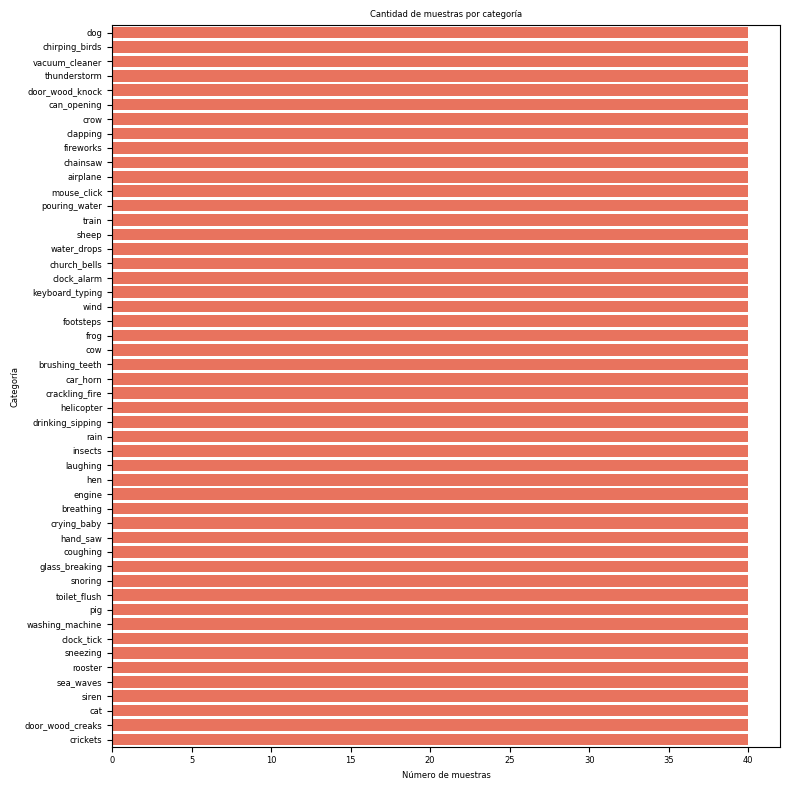

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,8))

sns.countplot(
    data=df,
    y="category",
    order=df["category"].value_counts().index,
    color="tomato"
)

plt.title("Cantidad de muestras por categoría", fontsize=6)
plt.xlabel("Número de muestras", fontsize=6)
plt.ylabel("Categoría", fontsize=6)
plt.yticks(fontsize=6) 
plt.xticks(fontsize=6)
plt.tight_layout()
plt.show()




Con este diagrama de barras se puede verificar mas fielmente de manera visual la cantidad de categorias y muestras que se encuentran en la metadata brindada para el dataset esc-50

---

Ahora veremos los folds para confirmar que se tienen 400 muestras para cada fold y estos van del 1 al 5, esto valida que se pueden utilizar los folds para splitting (folds 1-3 train, 4 val, 5 test) sin introducir sesgos.

In [8]:
df.groupby("fold").size()

fold
1    400
2    400
3    400
4    400
5    400
dtype: int64

In [9]:
df.groupby(["fold", "target"]).size().unstack(fill_value=0)


target,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
fold,,,,,,,,,,,,,,,,,,,,,
1,8,8,8,8,8,8,8,8,8,8,...,8,8,8,8,8,8,8,8,8,8
2,8,8,8,8,8,8,8,8,8,8,...,8,8,8,8,8,8,8,8,8,8
3,8,8,8,8,8,8,8,8,8,8,...,8,8,8,8,8,8,8,8,8,8
4,8,8,8,8,8,8,8,8,8,8,...,8,8,8,8,8,8,8,8,8,8
5,8,8,8,8,8,8,8,8,8,8,...,8,8,8,8,8,8,8,8,8,8


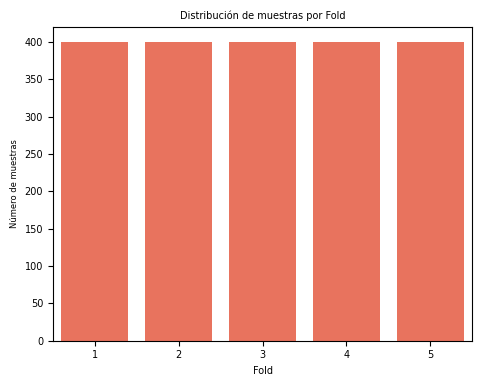

In [10]:
fold_counts = df.groupby("fold").size().reset_index(name="count")

plt.figure(figsize=(5,4))
sns.barplot(data=fold_counts, x="fold", y="count", color="tomato")

plt.title("Distribución de muestras por Fold", fontsize=7)
plt.xlabel("Fold", fontsize=7)
plt.ylabel("Número de muestras", fontsize=6)
plt.xticks(rotation=0)
plt.tight_layout()
plt.yticks(fontsize=7)
plt.xticks(fontsize=7)
plt.show()


Como se puede observar los folds estan correctamente balanceados como se esperaba conteniendo cada fila un fold, cada columna las clases y dentro de estas 8 muestras de la clase especifica en ese fold, lo cual genera un resultado de 400 si se multiplica 8 * 50, esto para cada uno de los 5 folds

---

#### Espectogramas y visualizacion de patrones

Se realizara una visualizacion de 5 clases aleatorias y para cada una de estas 5 muestras de los espectogramas con el fin de observar si existe algun patron a simple vista, esto es util para determinar si las entradas son correctas y coherentes para la CNN. 

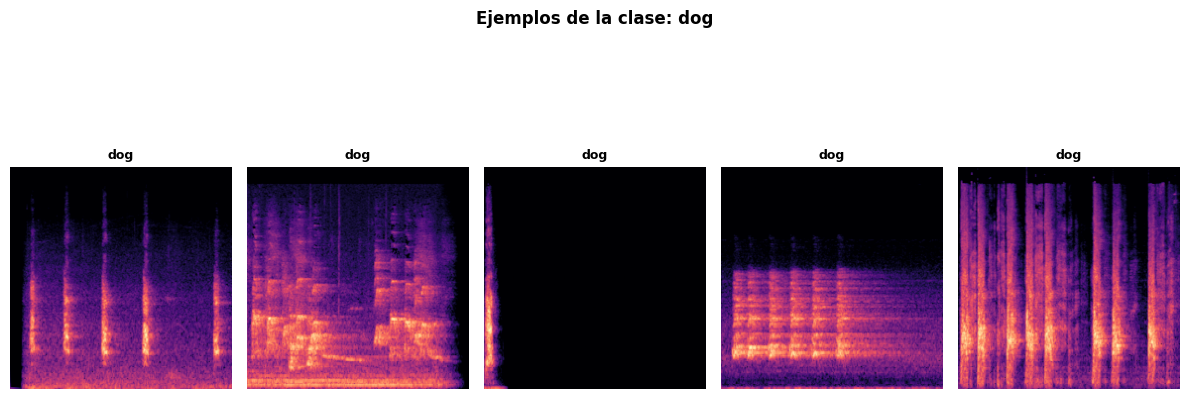

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Seleccionar aleatoriamente una categoría 
clase = "dog"

# Filtrar 5 muestras de esa clase 
ejemplos = df[df["category"] == clase].sample(5, random_state=None)

#  Visualización 
plt.figure(figsize=(12, 6))
for i, (_, fila) in enumerate(ejemplos.iterrows()):
    img = mpimg.imread(fila["spect_path"])
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{clase}", fontsize=9, fontweight="bold")

plt.suptitle(f"Ejemplos de la clase: {clase}", fontsize=12, fontweight="bold", y=0.92)
plt.tight_layout()
plt.show()


Como se puede observar existen ciertos picos y colas o desvanecimiento hacia la derecha, esto corresponderia a que los perros por lo general al momento de ladrar tienen un ataque rapido, osea un inicio bastante abrupto de energia, es por esta razon tambien que en la parte baja del pico se observa un color mas brillante.

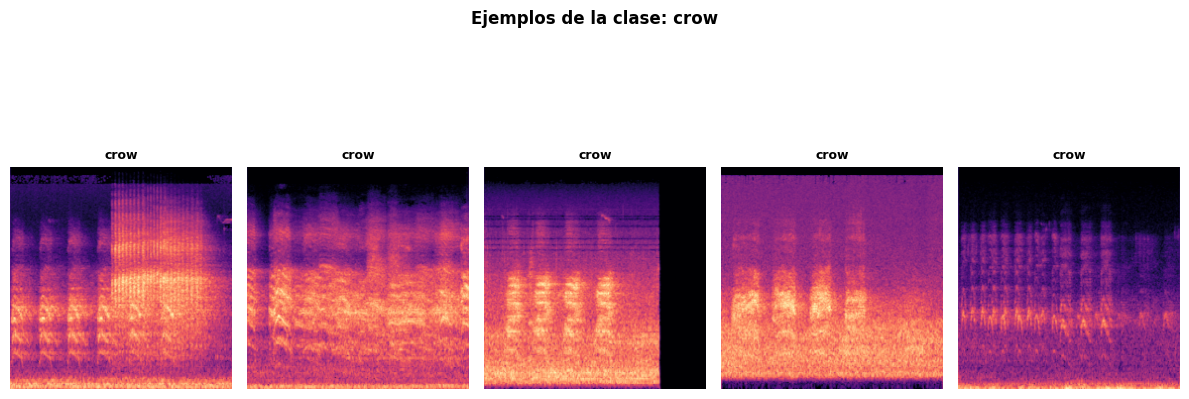

In [12]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Seleccionar aleatoriamente una categoría 
clase = "crow"

# Filtrar 5 muestras de esa clase 
ejemplos = df[df["category"] == clase].sample(5, random_state=None)

#  Visualización 
plt.figure(figsize=(12, 6))
for i, (_, fila) in enumerate(ejemplos.iterrows()):
    img = mpimg.imread(fila["spect_path"])
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{clase}", fontsize=9, fontweight="bold")

plt.suptitle(f"Ejemplos de la clase: {clase}", fontsize=12, fontweight="bold", y=0.92)
plt.tight_layout()
plt.show()


Como se puede observar para este caso, el cuervo presenta un patrón rítmico de picos verticales que se repiten en el tiempo, típico de llamadas cortas, secuenciales y resonantes. Esto contrasta con clases más continuas (como “rain” o “vacuum_cleaner”), que muestran espectrogramas más densos y uniformes.

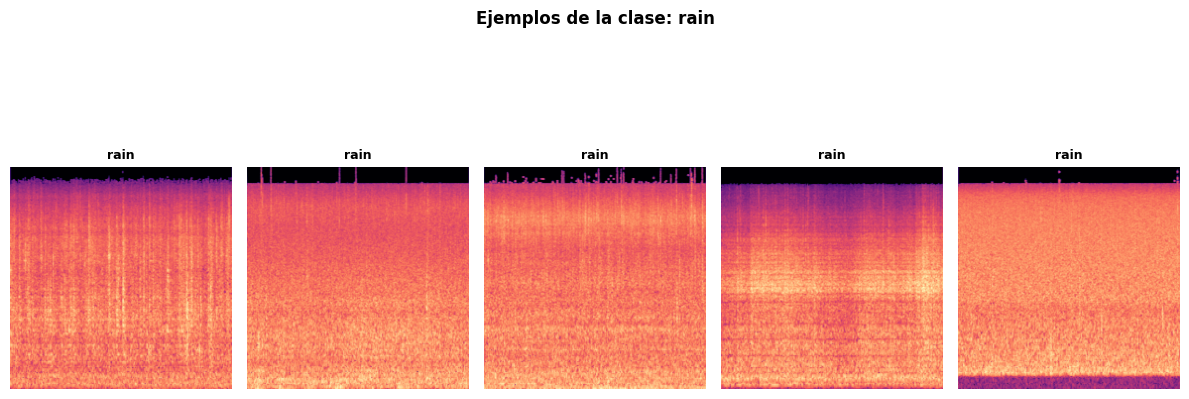

In [13]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Seleccionar aleatoriamente una categoría 
clase = "rain"

# Filtrar 5 muestras de esa clase 
ejemplos = df[df["category"] == clase].sample(5, random_state=None)

#  Visualización 
plt.figure(figsize=(12, 6))
for i, (_, fila) in enumerate(ejemplos.iterrows()):
    img = mpimg.imread(fila["spect_path"])
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{clase}", fontsize=9, fontweight="bold")

plt.suptitle(f"Ejemplos de la clase: {clase}", fontsize=12, fontweight="bold", y=0.92)
plt.tight_layout()
plt.show()


Como se menciono anteriormente el patrón visual de la lluvia se caracteriza por una textura uniforme y difusa, con energía distribuida en casi todas las frecuencias y sin picos repetitivos. Esto contrasta con clases impulsivas como dog o crow, donde aparecen estructuras verticales bien definidas.

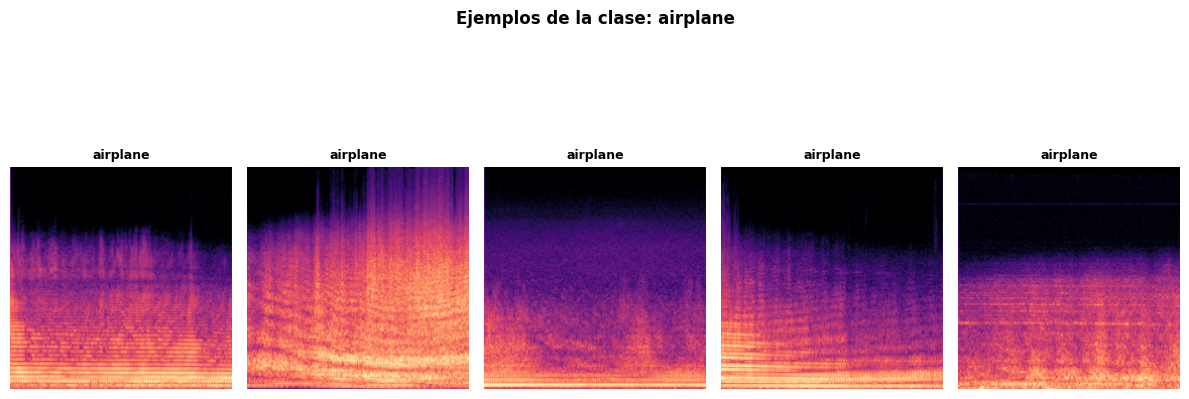

In [14]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

# Seleccionar aleatoriamente una categoría 
clase = "airplane"

# Filtrar 5 muestras de esa clase 
ejemplos = df[df["category"] == clase].sample(5, random_state=None)

#  Visualización 
plt.figure(figsize=(12, 6))
for i, (_, fila) in enumerate(ejemplos.iterrows()):
    img = mpimg.imread(fila["spect_path"])
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{clase}", fontsize=9, fontweight="bold")

plt.suptitle(f"Ejemplos de la clase: {clase}", fontsize=12, fontweight="bold", y=0.92)
plt.tight_layout()
plt.show()


En este caso, el sonido del avión genera un patrón de energía continua en bajas frecuencias, con variaciones suaves en el tiempo. Es un ruido mecánico sostenido, caracterizado por sus bandas horizontales y un gradiente de intensidad típico del paso de motores en movimiento.

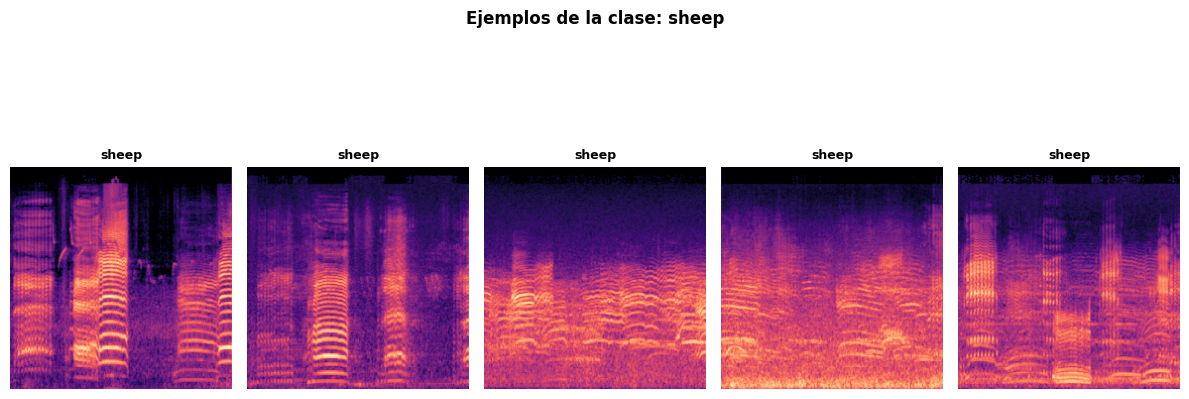

In [15]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

# Seleccionar aleatoriamente una categoría 
clase = "sheep"

# Filtrar 5 muestras de esa clase 
ejemplos = df[df["category"] == clase].sample(5, random_state=None)

#  Visualización 
plt.figure(figsize=(12, 6))
for i, (_, fila) in enumerate(ejemplos.iterrows()):
    img = mpimg.imread(fila["spect_path"])
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{clase}", fontsize=9, fontweight="bold")

plt.suptitle(f"Ejemplos de la clase: {clase}", fontsize=12, fontweight="bold", y=0.92)
plt.tight_layout()
plt.show()


Para el sonido de la oveja podemos observar que se producen patrones de armónicos claros y repetitivos, con bandas horizontales bien definidas y separadas, que reflejan la naturaleza vocal del balido. Es un sonido periódico y tonal, muy distinto de ruidos continuos como rain o vacuum_cleaner.

Como podemos observar en estos 5 ejemplos mostrados anteriormente, existen relaciones muy fuertes entre la posicion de los pixeles y el color de estos mismos, de modo que a simple vista podemos imaginar como se comporta el sonido teniendo en cuenta estos factores, por lo tanto son factores que la CNN tomara en cuenta a la hora de pasar los filtros cada uno de estos se ajustara de modo que se vayan obteniendo diferentes caracteristicas de la imagen por cada convolucion que se este realizando.

---

#### Normalizacion

Debido a que las imagenes seran entradas para la CNN de arquitectura ResNet es necesario aplicar una normalizacion sobre la misma calculando la media y la desviacion estandar primeramente para obtener estas dos estadisticas descriptivas que nos ayudaran a normalizar.

In [16]:
import numpy as np
from PIL import Image
from tqdm import tqdm

# Fijar seed para reproducibilidad
np.random.seed(42)

# Listado de rutas desde el DataFrame
rutas = df["spect_path"].tolist()

# Variables acumuladoras para media y media de cuadrados
num_imgs = len(rutas)  
mean = np.zeros(3)  # Para R, G, B
mean_square = np.zeros(3)  

for ruta in rutas:
    img = Image.open(ruta).convert("RGB")
    img_array = np.array(img) / 255.0
    mean += img_array.mean(axis=(0, 1))
    mean_square += (img_array ** 2).mean(axis=(0, 1))

# Calcular media y std finales
mean /= num_imgs
std = np.sqrt(mean_square / num_imgs - mean ** 2)

# Imprimir resultados
print("Media por canal (R, G, B):", mean)
print("Desviación estándar por canal (R, G, B):", std)

Media por canal (R, G, B): [0.4241387  0.1550668  0.31883597]
Desviación estándar por canal (R, G, B): [0.35462896 0.16410387 0.19566532]


Como se puede observar se obtuvo la media por cada canal en un intervalo de [0,1] ademas la desviacion estandar para cada canal de la misma manera en ese mismo intervalo, esto nos permitira realizar una normalizacion correcta de los valores de pixeles en cada imagen para que puedan ser procesados de manera optima por la CNN con arquitectura ResNet.

In [17]:
import torch
from torch.utils.data import Dataset, DataLoader

# Estadísticas calculadas previamente
MEAN = mean
STD  = std

class ESC50Dataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Cargar imagen desde la ruta
        img_path = self.df.iloc[idx]["spect_path"]
        img = Image.open(img_path).convert("RGB")

        # Convertir a tensor en rango [0,1]
        img_array = np.array(img, dtype=np.float32) / 255.0
        img_tensor = torch.from_numpy(img_array).permute(2, 0, 1)

        # Normalización explícita canal por canal
        for c in range(3):
            img_tensor[c] = (img_tensor[c] - MEAN[c]) / STD[c]

        # Etiqueta numérica
        label = self.df.iloc[idx]["target"]

        return img_tensor, label

# Ejemplo de uso 
#dataset = ESC50Dataset(df)  
#dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

#print("Total de muestras:", len(dataset))
#batch = next(iter(dataloader))
#print("Tamaño de batch:", batch[0].shape)


Se puede observar que se tomaron todas las imagenes para la normalizacion y se obtuvo un tamano de batch de [32,3,224,224] lo cual es correcto tomando en cuenta que se esta trabajando con imagenes de 3 canales de 224x224. Estos valores se cargan a Dataset y Dataloader para posteriormente poder utilizarlos en entrenamiento

---


#### Division del conjunto de entrenamiento, validation y test

Se utilizaran los folds dados los cuales son 5 y cada uno con 400 muestras de modo que tomaremos, 1200 muestras osea 3 folds para entrenamiento y validacion de 400 muestras y de igual manera para test con 400 muestras.

In [18]:
# TEST FIJO: fold 5
df_test = df[df["fold"] == 5].reset_index(drop=True)
test_dataset = ESC50Dataset(df_test)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# TRAIN/VAL: folds 1,2,3,4
df_train_val = df[df["fold"].isin([1, 2, 3, 4])].reset_index(drop=True)

print(f"Train/Val: {len(df_train_val)} muestras | Test: {len(df_test)} muestras")

Train/Val: 1600 muestras | Test: 400 muestras


In [19]:
# Dataset para cada split
train_dataset = ESC50Dataset(df_train_val)
test_dataset = ESC50Dataset(df_test)

# DataLoaders
batch_size = 32  # 
train_val_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Verificar un batch
images, labels = next(iter(train_val_dataloader))
print("Train batch shape:", images.shape)  # [32, 3, 224, 224]
print("Train labels shape:", labels.shape)  # [32]

Train batch shape: torch.Size([32, 3, 224, 224])
Train labels shape: torch.Size([32])


Se genera un total de 32 imagenes normalizadas con 3 canales y de 224x224 para cada batch estos se utilizaran para el entrenamiento de los kernel que son parte de la CNN. 

---

#### Resnet 18

Utilizaremos para el entrenamiento una arquitectura de redes neuronales profundas que utiliza bloques residuales con skip connections, permitiendo que la red aprenda funciones residuales en lugar de funciones completas. Esto facilita el entrenamiento de modelos muy profundos, evitando la degradación del rendimiento y mejorando la precisión en tareas de visión.

- implementar una clase para los bloques residuales de resnet los cuales se deben de aplicar para minimizar el error en capas profundas

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F

#Mantener constante el kernel size de 3 y el padding de 1
# Configuración de convolución 3x3
conv_k_3 = lambda in_channels, out_channels, stride: nn.Conv2d(
    in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False
)

#Clase para los bloques residuales
# Bloque residual básico (para ResNet-18)
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = conv_k_3(in_channels, out_channels, stride)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = conv_k_3(out_channels, out_channels, 1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
            
    #funcion para realizar la suma de la salida de un bloque a la salida del bloque siguiente
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out
    




- Implementar la clase resnet ahora si una vez implementada la clase residual

In [21]:
# ResNet-18 adaptado para ESC-50
class ResNet18(nn.Module):
    def __init__(self, num_classes=50):
        super(ResNet18, self).__init__()
        self.in_channels = 64
        # Conv inicial y max pooling (estándar para 224x224)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        # Etapas: 2 bloques por etapa (64, 128, 256, 512 canales)
        self.layer1 = self.make_layer(64, 2, stride=1)
        self.layer2 = self.make_layer(128, 2, stride=2)
        self.layer3 = self.make_layer(256, 2, stride=2)
        self.layer4 = self.make_layer(512, 2, stride=2)
        # Average pooling y FC
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def make_layer(self, out_channels, num_blocks, stride):
        layers = []
        layers.append(BasicBlock(self.in_channels, out_channels, stride))
        self.in_channels = out_channels
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))  # [batch_size, 64, 112, 112]
        x = self.maxpool(x)                     # [batch_size, 64, 56, 56]
        x = self.layer1(x)                      # [batch_size, 64, 56, 56]
        x = self.layer2(x)                      # [batch_size, 128, 28, 28]
        x = self.layer3(x)                      # [batch_size, 256, 14, 14]
        x = self.layer4(x)                      # [batch_size, 512, 7, 7]
        x = self.avgpool(x)                     # [batch_size, 512, 1, 1]
        x = x.view(x.size(0), -1)               # [batch_size, 512]
        x = self.fc(x)                          # [batch_size, 50]
        return x

# Instanciar modelo
model_resnet18 = ResNet18(num_classes=50)

# Optimizador (ajustado para ESC-50)
optimizer = torch.optim.SGD(model_resnet18.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)